In [8]:
df[df['TRADEPRICE'].notna()]['ACTION'].value_counts()

ACTION
2    1073000
Name: count, dtype: int64

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df = pd.read_csv('data.csv')
print(f'Строк: {len(df):,}')
df['TIME'].describe()

Строк: 7,612,685


count    7.612685e+06
mean     1.368583e+11
std      2.757265e+10
min      1.000000e+11
25%      1.118497e+11
50%      1.330499e+11
75%      1.625541e+11
max      1.844597e+11
Name: TIME, dtype: float64

In [2]:
# TIME = HHMMSS + 6 цифр микросекунд, например 184459_475316 -> 18:44:59.475316
# Переводим в секунды от начала дня для удобства
t = df['TIME'].astype(str).str.zfill(12)
df['hh'] = t.str[:2].astype(int)
df['mm'] = t.str[2:4].astype(int)
df['ss'] = t.str[4:6].astype(int)
df['us'] = t.str[6:].astype(int)

df['time_sec'] = df['hh'] * 3600 + df['mm'] * 60 + df['ss'] + df['us'] / 1e6

print('Диапазон времени:')
print(f"  min: {df['hh'].min():02d}:{df['mm'][df['time_sec'].idxmin()]:02d}:{df['ss'][df['time_sec'].idxmin()]:02d}")
print(f"  max: {df['hh'].max():02d}:{df['mm'][df['time_sec'].idxmax()]:02d}:{df['ss'][df['time_sec'].idxmax()]:02d}")

# Доля значений на границах
q01 = df['time_sec'].quantile(0.01)
q99 = df['time_sec'].quantile(0.99)
print(f'\n1% перцентиль:  {q01:.1f} сек ({q01/3600:.4f} ч)')
print(f'99% перцентиль: {q99:.1f} сек ({q99/3600:.4f} ч)')
print(f'\nЗначений < q1%:  {(df["time_sec"] < q01).sum():,} ({(df["time_sec"] < q01).mean()*100:.2f}%)')
print(f'Значений > q99%: {(df["time_sec"] > q99).sum():,} ({(df["time_sec"] > q99).mean()*100:.2f}%)')

Диапазон времени:
  min: 10:00:00
  max: 18:44:59

1% перцентиль:  36007.6 сек (10.0021 ч)
99% перцентиль: 67154.2 сек (18.6540 ч)

Значений < q1%:  76,126 (1.00%)
Значений > q99%: 76,127 (1.00%)


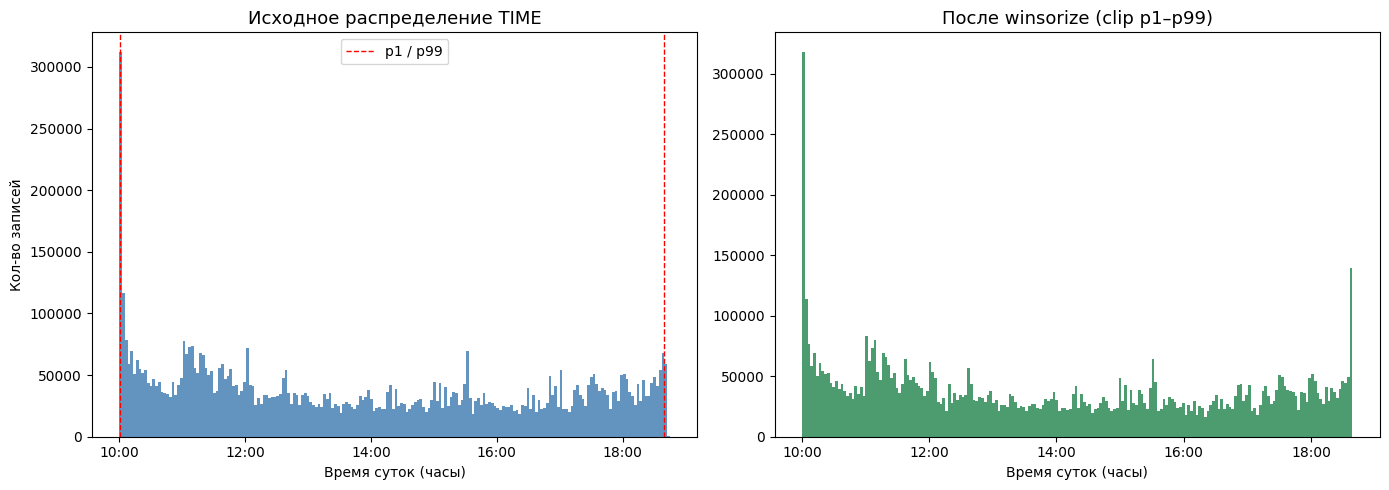

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Исходное распределение ---
ax = axes[0]
ax.hist(df['time_sec'] / 3600, bins=200, color='steelblue', edgecolor='none', alpha=0.85)
ax.set_title('Исходное распределение TIME', fontsize=13)
ax.set_xlabel('Время суток (часы)')
ax.set_ylabel('Кол-во записей')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):02d}:{int((x%1)*60):02d}'))
ax.axvline(q01/3600, color='red', linestyle='--', linewidth=1, label=f'p1 / p99')
ax.axvline(q99/3600, color='red', linestyle='--', linewidth=1)
ax.legend(fontsize=10)

# --- После обрезки хвостов (winsorize на p1/p99) ---
df['time_sec_clipped'] = df['time_sec'].clip(lower=q01, upper=q99)

ax2 = axes[1]
ax2.hist(df['time_sec_clipped'] / 3600, bins=200, color='seagreen', edgecolor='none', alpha=0.85)
ax2.set_title('После winsorize (clip p1–p99)', fontsize=13)
ax2.set_xlabel('Время суток (часы)')
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):02d}:{int((x%1)*60):02d}'))

plt.tight_layout()
plt.savefig('time_distribution.png', dpi=150)
plt.show()

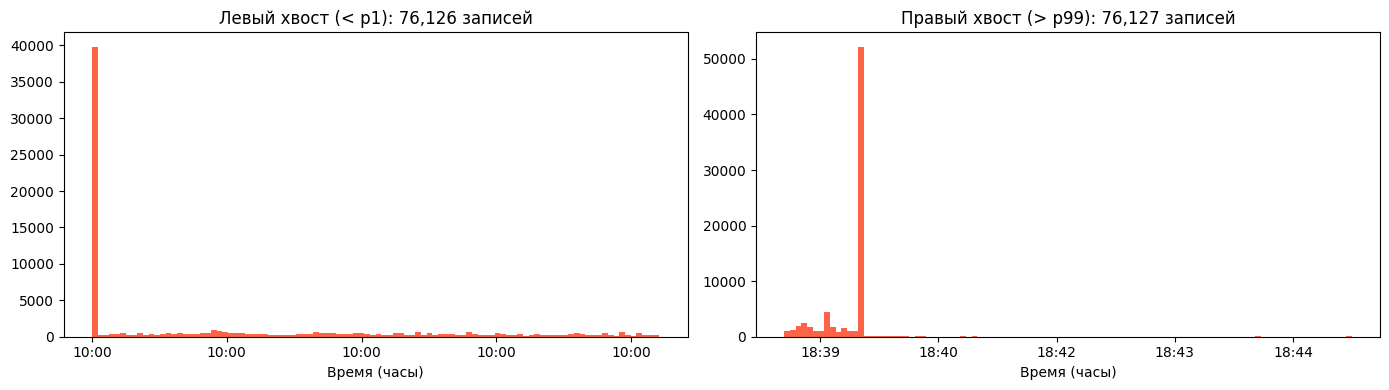


Левый хвост — топ-5 значений времени:
time_sec
36000.000000    39667
36001.727650       31
36001.351280       29
36003.374749       29
36004.350579       29
Name: count, dtype: int64

Правый хвост — топ-5 значений времени:
time_sec
67201.001030    51551
67157.936152       61
67166.946079       38
67181.946054       37
67170.473907       33
Name: count, dtype: int64


In [ ]:
# Посмотрим на хвосты подробнее
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

left_tail = df[df['time_sec'] < q01]['time_sec'] / 3600
right_tail = df[df['time_sec'] > q99]['time_sec'] / 3600

axes[0].hist(left_tail, bins=100, color='tomato', edgecolor='none')
axes[0].set_title(f'Левый хвост (< p1): {len(left_tail):,} записей', fontsize=12)
axes[0].set_xlabel('Время (часы)')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):02d}:{int((x%1)*60):02d}'))

axes[1].hist(right_tail, bins=100, color='tomato', edgecolor='none')
axes[1].set_title(f'Правый хвост (> p99): {len(right_tail):,} записей', fontsize=12)
axes[1].set_xlabel('Время (часы)')
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):02d}:{int((x%1)*60):02d}'))

plt.tight_layout()
plt.show()

print('\nЛевый хвост — топ-5 значений времени:')
print(df[df['time_sec'] < q01]['time_sec'].value_counts().head())
print('\nПравый хвост — топ-5 значений времени:')
print(df[df['time_sec'] > q99]['time_sec'].value_counts().head())

In [5]:
# Итог: сохраняем колонку с обработанным временем
print('time_sec_clipped — готово к использованию')
print(df['time_sec_clipped'].describe())

time_sec_clipped — готово к использованию
count    7.612685e+06
mean     4.992371e+04
std      1.000026e+04
min      3.600757e+04
25%      4.072973e+04
50%      4.864986e+04
75%      5.915410e+04
max      6.715423e+04
Name: time_sec_clipped, dtype: float64


## Заявок в секунду

In [6]:
# Считаем без дефолтных заявок 10:00:00 (TIME == 100000000000)
df_real = df[df['TIME'] != 100000000000].copy()
print(f'Строк без дефолтного 10:00:00: {len(df_real):,} (убрали {len(df)-len(df_real):,})')

# Секунда торгов = floor(time_sec)
df_real['second'] = df_real['time_sec'].astype(int)
rps = df_real.groupby('second').size().rename('orders')

print('\nЗаявок в секунду:')
print(rps.describe().to_string())
print(f'\nМакс. всплеск: {rps.max()} заявок в {rps.idxmax()//3600:02d}:{(rps.idxmax()%3600)//60:02d}:{rps.idxmax()%60:02d}')

# Топ-5 секунд по активности
print('\nТоп-5 секунд:')
for sec, cnt in rps.nlargest(5).items():
    print(f'  {sec//3600:02d}:{(sec%3600)//60:02d}:{sec%60:02d} — {cnt} заявок')

Строк без дефолтного 10:00:00: 7,573,018 (убрали 39,667)

Заявок в секунду:
count    31495.000000
mean       240.451437
std        390.793292
min          1.000000
25%        110.000000
50%        170.000000
75%        275.000000
max      51691.000000

Макс. всплеск: 51691 заявок в 18:40:01

Топ-5 секунд:
  18:40:01 — 51691 заявок
  10:00:01 — 6991 заявок
  17:17:00 — 5898 заявок
  16:50:21 — 5678 заявок
  10:00:03 — 5395 заявок


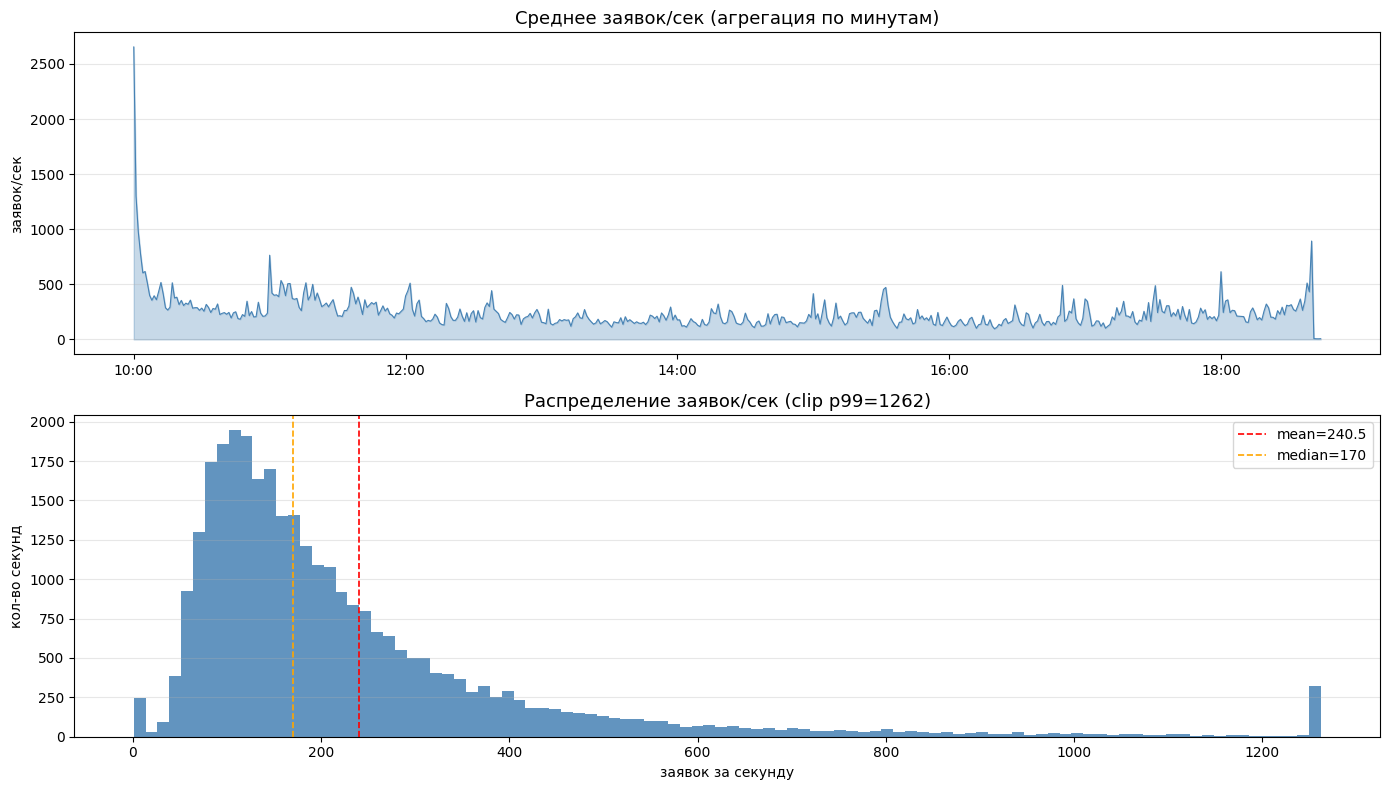

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- Заявок в секунду по всему дню (агрегация по минутам) ---
rps_per_min = rps.groupby(rps.index // 60).sum() / 60  # среднее заявок/сек внутри минуты
x_hours = rps_per_min.index / 60  # минуты -> часы

ax1 = axes[0]
ax1.plot(x_hours, rps_per_min.values, linewidth=0.8, color='steelblue')
ax1.fill_between(x_hours, rps_per_min.values, alpha=0.3, color='steelblue')
ax1.set_title('Среднее заявок/сек (агрегация по минутам)', fontsize=13)
ax1.set_ylabel('заявок/сек')
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):02d}:{int((x%1)*60):02d}'))
ax1.grid(axis='y', alpha=0.3)

# --- Распределение rps (гистограмма) ---
ax2 = axes[1]
p99_rps = rps.quantile(0.99)
ax2.hist(rps.clip(upper=p99_rps), bins=100, color='steelblue', edgecolor='none', alpha=0.85)
ax2.set_title(f'Распределение заявок/сек (clip p99={p99_rps:.0f})', fontsize=13)
ax2.set_xlabel('заявок за секунду')
ax2.set_ylabel('кол-во секунд')
ax2.axvline(rps.mean(), color='red', linestyle='--', linewidth=1.2, label=f'mean={rps.mean():.1f}')
ax2.axvline(rps.median(), color='orange', linestyle='--', linewidth=1.2, label=f'median={rps.median():.0f}')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()